# Neural Network: Single Perceptron with Single Input

A perceptron is a single neuron that takes inputs, multiplies by weights, adds a bias, and produces an output:

$$\hat{y} = wx + b$$

We'll train this on the [TV Marketing Dataset](https://www.kaggle.com/datasets/devzohaib/tvmarketingcsv) to predict sales from advertising spend.

## Architecture Diagram

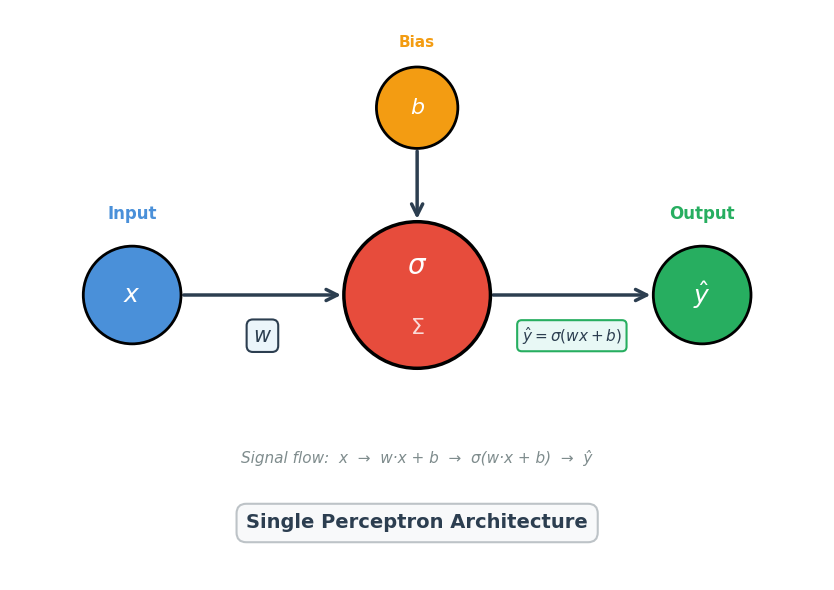

In [85]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.set_xlim(0, 10)
ax.set_ylim(0, 7)
ax.set_aspect('equal')
ax.axis('off')

# Colors
c_input = '#4A90D9'
c_neuron = '#E74C3C'
c_output = '#27AE60'
c_bias = '#F39C12'
c_arrow = '#2C3E50'

# Input node
input_circle = plt.Circle((1.5, 3.5), 0.6, color=c_input, ec='black', lw=2, zorder=5)
ax.add_patch(input_circle)
ax.text(1.5, 3.5, '$x$', ha='center', va='center', fontsize=18, fontweight='bold', color='white', zorder=6)
ax.text(1.5, 4.5, 'Input', ha='center', va='center', fontsize=12, fontweight='bold', color=c_input)

# Bias node
bias_circle = plt.Circle((5, 5.8), 0.5, color=c_bias, ec='black', lw=2, zorder=5)
ax.add_patch(bias_circle)
ax.text(5, 5.8, '$b$', ha='center', va='center', fontsize=16, fontweight='bold', color='white', zorder=6)
ax.text(5, 6.6, 'Bias', ha='center', va='center', fontsize=11, fontweight='bold', color=c_bias)

# Neuron (summation + activation)
neuron_circle = plt.Circle((5, 3.5), 0.9, color=c_neuron, ec='black', lw=2.5, zorder=5)
ax.add_patch(neuron_circle)
ax.text(5, 3.85, '$\sigma$', ha='center', va='center', fontsize=20, fontweight='bold', color='white', zorder=6)
ax.text(5, 3.1, '$\\Sigma$', ha='center', va='center', fontsize=16, color='#FADBD8', zorder=6)

# Output node
output_circle = plt.Circle((8.5, 3.5), 0.6, color=c_output, ec='black', lw=2, zorder=5)
ax.add_patch(output_circle)
ax.text(8.5, 3.5, '$\\hat{y}$', ha='center', va='center', fontsize=18, fontweight='bold', color='white', zorder=6)
ax.text(8.5, 4.5, 'Output', ha='center', va='center', fontsize=12, fontweight='bold', color=c_output)

# Arrows
arrow_kw = dict(arrowstyle='->', color=c_arrow, lw=2.5, mutation_scale=20)

# Input → Neuron
ax.annotate('', xy=(4.1, 3.5), xytext=(2.1, 3.5), arrowprops=arrow_kw)
ax.text(3.1, 3.0, '$w$', ha='center', va='center', fontsize=15, fontweight='bold', 
        color=c_arrow, bbox=dict(boxstyle='round,pad=0.3', facecolor='#EBF5FB', edgecolor=c_arrow, lw=1.5))

# Bias → Neuron
ax.annotate('', xy=(5, 4.4), xytext=(5, 5.3), arrowprops=arrow_kw)

# Neuron → Output
ax.annotate('', xy=(7.9, 3.5), xytext=(5.9, 3.5), arrowprops=arrow_kw)
ax.text(6.9, 3.0, '$\\hat{y} = \\sigma(wx + b)$', ha='center', va='center', fontsize=11, 
        color=c_arrow, bbox=dict(boxstyle='round,pad=0.3', facecolor='#E8F8F5', edgecolor=c_output, lw=1.5))

# Title
ax.text(5, 0.7, 'Single Perceptron Architecture', ha='center', va='center', 
        fontsize=14, fontweight='bold', color='#2C3E50',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#F8F9FA', edgecolor='#BDC3C7', lw=1.5))

# Signal flow legend
ax.text(5, 1.5, 'Signal flow:  x  →  w·x + b  →  σ(w·x + b)  →  ŷ', 
        ha='center', va='center', fontsize=11, style='italic', color='#7F8C8D')

plt.tight_layout()
plt.show()

In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [76]:
# Load dataset and extract feature vectors
df = pd.read_csv('res/tvmarketing.csv')
print(f"Dataset: {df.shape[0]} samples, {df.shape[1]} columns")
print(df.head())

tv_vec = df['TV'].values
sales_vec = df['Sales'].values
print(f"\ntv_vec: {tv_vec.shape}, sales_vec: {sales_vec.shape}")

Dataset: 200 samples, 2 columns
      TV  Sales
0  230.1   22.1
1   44.5   10.4
2   17.2    9.3
3  151.5   18.5
4  180.8   12.9

tv_vec: (200,), sales_vec: (200,)


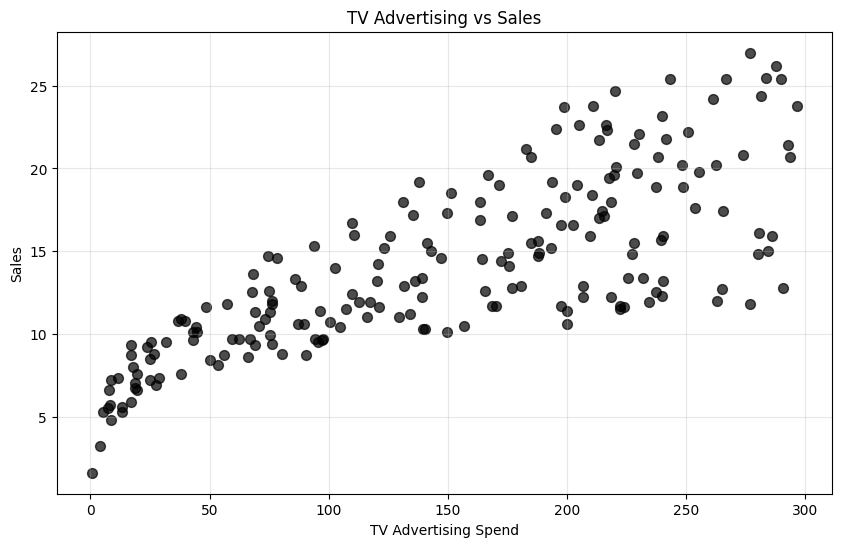

In [77]:
# Scatter plot: TV Advertising vs Sales
plt.figure(figsize=(10, 6))
plt.scatter(tv_vec, sales_vec, color='black', alpha=0.7, s=50)
plt.xlabel('TV Advertising Spend')
plt.ylabel('Sales')
plt.title('TV Advertising vs Sales')
plt.grid(True, alpha=0.3)
plt.show()

## Training Process

1. **Forward Pass**: Compute predictions → $\hat{y} = wx + b$
2. **Calculate Loss**: Measure error → $\text{MSE} = \frac{1}{n}\sum(y - \hat{y})^2$
3. **Backward Pass**: Compute gradients using partial derivatives
4. **Update Parameters**: Adjust $w$ and $b$ using gradient descent
5. **Repeat** until convergence

In [78]:
# Initialize weights and bias
def initialize_weights_bias(seed=42):
    np.random.seed(seed)
    w = np.random.randn() * 0.01  # small random weight
    b = 0.0
    return (w, b)

# Hyperparameters
learning_rate = 0.00001
iterations = int(1 / learning_rate)  # 100,000

w, b = initialize_weights_bias()
print(f"w = {w:.6f}, b = {b}")
print(f"learning_rate = {learning_rate}, iterations = {iterations}")

w = 0.004967, b = 0.0
learning_rate = 1e-05, iterations = 99999


In [79]:
# Forward pass: predicted_sales = w * tv + b
def compute_predicted_sales(tv_data, w, b):
    return w * tv_data + b

# Loss function: Mean Squared Error
def calculate_loss(y_actual, y_predicted):
    return np.mean((y_actual - y_predicted) ** 2)

# Test
y_pred = compute_predicted_sales(tv_vec, w, b)
loss = calculate_loss(sales_vec, y_pred)
print(f"Initial predictions range: [{y_pred.min():.2f}, {y_pred.max():.2f}]")
print(f"Initial loss (MSE): {loss:.4f}")

Initial predictions range: [0.00, 1.47]
Initial loss (MSE): 200.4837


## Back Propagation and Partial Derivatives

Back Propagation is the process of computing gradients to update the model parameters. It uses **partial derivatives** to determine how much each parameter contributes to the loss.

### Why Partial Derivatives?

Partial derivatives tell us the **rate of change** of the loss with respect to each parameter. These are essential for:
- Understanding how changes in $w$ and $b$ affect the loss
- Computing the direction to adjust parameters to minimize loss
- Implementing gradient descent optimization

### Computing Gradients Using Partial Derivatives

For our simple perceptron with loss function:
$$\text{Loss} = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

where $\hat{y}_i = w \cdot x_i + b$

We compute the partial derivatives:

**Partial derivative with respect to weight:**
$$\frac{\partial \text{Loss}}{\partial w} = \frac{1}{n}\sum_{i=1}^{n} 2(y_i - \hat{y}_i) \cdot (-x_i) = -\frac{2}{n}\sum_{i=1}^{n} (y_i - \hat{y}_i) \cdot x_i$$

**Partial derivative with respect to bias:**
$$\frac{\partial \text{Loss}}{\partial b} = \frac{1}{n}\sum_{i=1}^{n} 2(y_i - \hat{y}_i) \cdot (-1) = -\frac{2}{n}\sum_{i=1}^{n} (y_i - \hat{y}_i)$$

### Gradient Descent Update Rule

Using these partial derivatives, we update the parameters:

$$w_{\text{new}} = w_{\text{old}} - \alpha \cdot \frac{\partial \text{Loss}}{\partial w}$$

$$b_{\text{new}} = b_{\text{old}} - \alpha \cdot \frac{\partial \text{Loss}}{\partial b}$$

where $\alpha$ is the **learning rate** - a small positive constant that controls the step size.

### Interpretation

- **Positive gradient**: The loss increases as the parameter increases. We should decrease the parameter.
- **Negative gradient**: The loss decreases as the parameter increases. We should increase the parameter.
- **Large gradient**: Large change needed in the parameter.
- **Small gradient**: Small adjustment needed in the parameter.

In [80]:
# Backpropagation: compute gradients via partial derivatives
# ∂Loss/∂w = -2/n * Σ(error * x)
# ∂Loss/∂b = -2/n * Σ(error)
def back_propagation(y_actual, y_predicted, tv_data):
    n = len(y_actual)
    errors = y_actual - y_predicted
    dw = -2.0 / n * np.sum(errors * tv_data)
    db = -2.0 / n * np.sum(errors)
    return (dw, db)

# Gradient descent: update parameters
# w_new = w - α * ∂Loss/∂w
# b_new = b - α * ∂Loss/∂b
def update_weight_bias(w, b, dw, db, learning_rate):
    return (w - learning_rate * dw, b - learning_rate * db)

# Test
dw, db = back_propagation(sales_vec, y_pred, tv_vec)
print(f"Gradients → dw: {dw:.4f}, db: {db:.4f}")
w_test, b_test = update_weight_bias(w, b, dw, db, learning_rate)
print(f"After 1 update → w: {w:.6f} → {w_test:.6f}, b: {b:.6f} → {b_test:.6f}")

Gradients → dw: -4533.4304, db: -26.5842
After 1 update → w: 0.004967 → 0.050301, b: 0.000000 → 0.000266


In [81]:
# Training loop: fixed iterations (100K)
def train_perceptron(tv_data, y_actual, w_init, b_init, learning_rate, iterations):
    w, b = w_init, b_init
    loss_history = []
    
    for i in range(iterations):
        y_pred = compute_predicted_sales(tv_data, w, b)
        loss = calculate_loss(y_actual, y_pred)
        loss_history.append(loss)
        dw, db = back_propagation(y_actual, y_pred, tv_data)
        w, b = update_weight_bias(w, b, dw, db, learning_rate)
        
        if (i + 1) % 10000 == 0:
            print(f"  Iteration {i+1:>6}/{iterations} - Loss: {loss:.4f}")
    
    return {'w': w, 'b': b, 'loss_history': loss_history}

print("Training with fixed 100K iterations...")
results = train_perceptron(tv_vec, sales_vec, w, b, learning_rate, iterations)
print(f"\nFinal → w: {results['w']:.6f}, b: {results['b']:.6f}")
print(f"Loss: {results['loss_history'][0]:.4f} → {results['loss_history'][-1]:.4f}")

Training with fixed 100K iterations...
  Iteration  10000/99999 - Loss: 21.8315
  Iteration  20000/99999 - Loss: 20.7409
  Iteration  30000/99999 - Loss: 19.7554
  Iteration  40000/99999 - Loss: 18.8649
  Iteration  50000/99999 - Loss: 18.0601
  Iteration  60000/99999 - Loss: 17.3329
  Iteration  70000/99999 - Loss: 16.6758
  Iteration  80000/99999 - Loss: 16.0820
  Iteration  90000/99999 - Loss: 15.5454

Final → w: 0.069055, b: 2.795233
Loss: 200.4837 → 15.0605


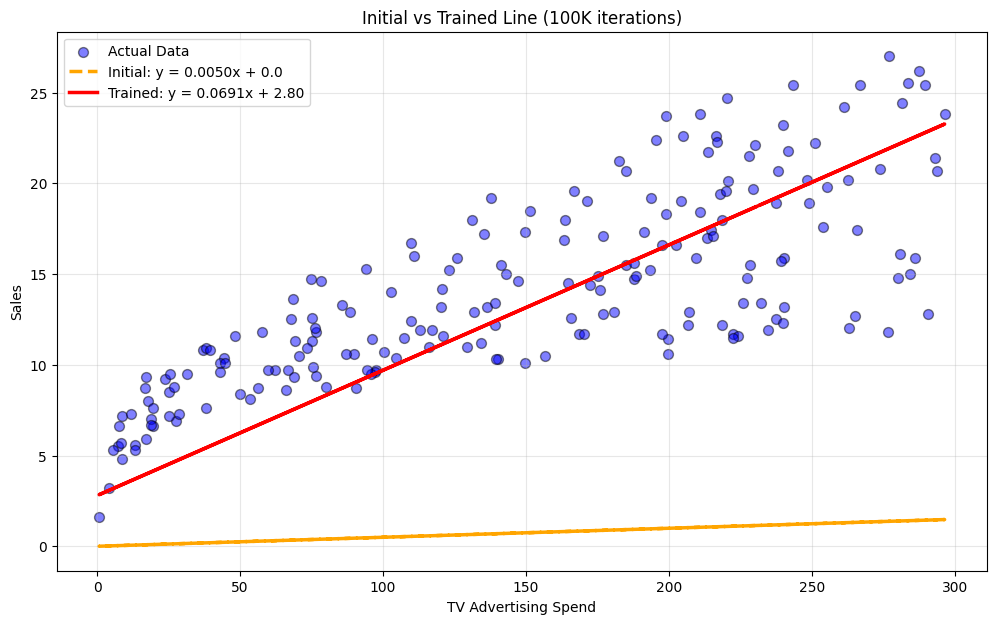

In [82]:
# Plot: Initial line vs Trained line
w_final, b_final = results['w'], results['b']
y_initial = compute_predicted_sales(tv_vec, w, b)
y_final = compute_predicted_sales(tv_vec, w_final, b_final)

plt.figure(figsize=(12, 7))
plt.scatter(tv_vec, sales_vec, alpha=0.5, color='blue', s=50, label='Actual Data', edgecolors='k')
plt.plot(tv_vec, y_initial, color='orange', linewidth=2.5, linestyle='--', label=f'Initial: y = {w:.4f}x + {b:.1f}')
plt.plot(tv_vec, y_final, color='red', linewidth=2.5, label=f'Trained: y = {w_final:.4f}x + {b_final:.2f}')
plt.xlabel('TV Advertising Spend')
plt.ylabel('Sales')
plt.title('Initial vs Trained Line (100K iterations)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

In [83]:
# Training loop: dynamic iterations with early stopping
# Stops when loss doesn't change for `patience` consecutive iterations
def train_perceptron_with_early_stopping(tv_data, y_actual, w_init, b_init, learning_rate, 
                                        patience=1000, tolerance=1e-6):
    w, b = w_init, b_init
    loss_history = []
    no_change_count = 0
    iteration = 0
    
    while True:
        y_pred = compute_predicted_sales(tv_data, w, b)
        loss = calculate_loss(y_actual, y_pred)
        loss_history.append(loss)
        
        # Check convergence
        if len(loss_history) > 1:
            loss_change = abs(loss_history[-1] - loss_history[-2])
            no_change_count = no_change_count + 1 if loss_change <= tolerance else 0
            
            if no_change_count >= patience:
                print(f"  Converged at iteration {iteration+1} (loss stable for {patience} iterations)")
                break
        
        dw, db = back_propagation(y_actual, y_pred, tv_data)
        w, b = update_weight_bias(w, b, dw, db, learning_rate)
        
        if (iteration + 1) % 50000 == 0:
            print(f"  Iteration {iteration+1} - Loss: {loss:.6f} - Stable count: {no_change_count}/{patience}")
        
        iteration += 1
    
    return {'w': w, 'b': b, 'loss_history': loss_history, 
            'iterations_trained': iteration + 1, 'converged': True}

print("Training with early stopping (dynamic iterations)...")
results_early_stopping = train_perceptron_with_early_stopping(tv_vec, sales_vec, w, b, learning_rate)
print(f"\nIterations: {results_early_stopping['iterations_trained']}")
print(f"Final → w: {results_early_stopping['w']:.6f}, b: {results_early_stopping['b']:.6f}")
print(f"Loss: {results_early_stopping['loss_history'][0]:.4f} → {results_early_stopping['loss_history'][-1]:.4f}")

Training with early stopping (dynamic iterations)...
  Iteration 50000 - Loss: 18.060145 - Stable count: 0/1000
  Iteration 100000 - Loss: 15.060490 - Stable count: 0/1000
  Iteration 150000 - Loss: 13.253010 - Stable count: 0/1000
  Iteration 200000 - Loss: 12.163890 - Stable count: 0/1000
  Iteration 250000 - Loss: 11.507626 - Stable count: 0/1000
  Iteration 300000 - Loss: 11.112187 - Stable count: 0/1000
  Iteration 350000 - Loss: 10.873910 - Stable count: 0/1000
  Iteration 400000 - Loss: 10.730333 - Stable count: 0/1000
  Iteration 450000 - Loss: 10.643819 - Stable count: 0/1000
  Converged at iteration 479065 (loss stable for 1000 iterations)

Iterations: 479065
Final → w: 0.050691, b: 6.411495
Loss: 200.4837 → 10.6104


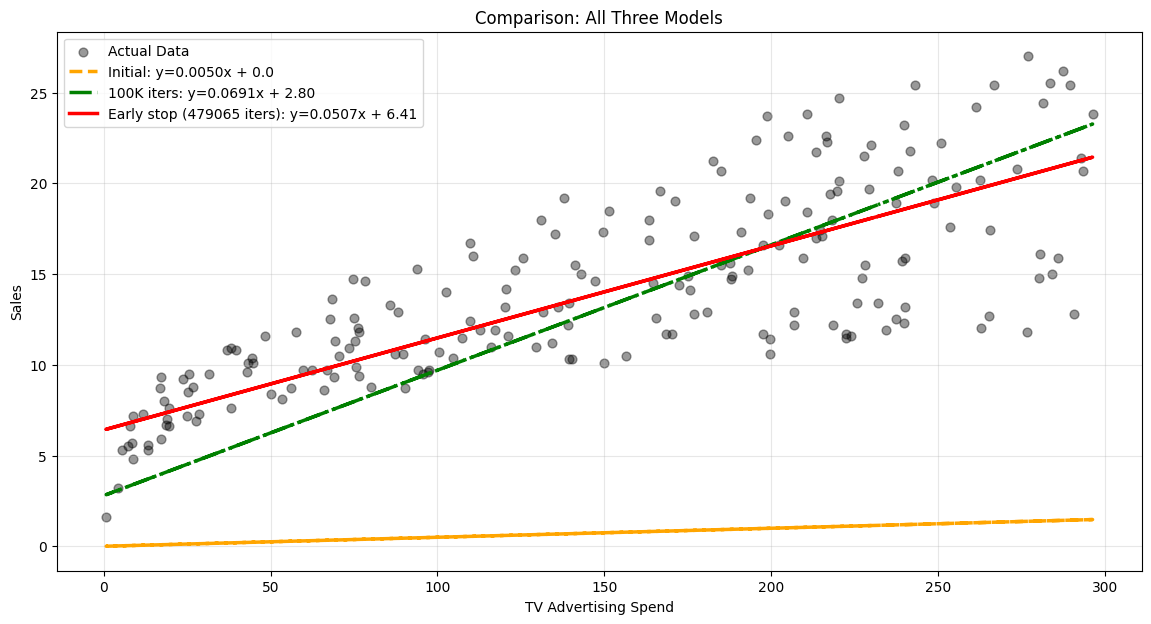

Fixed 100K  → loss: 15.0605
Early stop  → loss: 10.6104 (479065 iterations)


In [84]:
# Comparison: Initial vs Fixed Training vs Early Stopping
w_es, b_es = results_early_stopping['w'], results_early_stopping['b']

plt.figure(figsize=(14, 7))
plt.scatter(tv_vec, sales_vec, alpha=0.4, color='black', s=40, label='Actual Data')
plt.plot(tv_vec, compute_predicted_sales(tv_vec, w, b), 
         color='orange', linewidth=2.5, linestyle='--', label=f'Initial: y={w:.4f}x + {b:.1f}')
plt.plot(tv_vec, compute_predicted_sales(tv_vec, w_final, b_final), 
         color='green', linewidth=2.5, linestyle='-.', label=f'100K iters: y={w_final:.4f}x + {b_final:.2f}')
plt.plot(tv_vec, compute_predicted_sales(tv_vec, w_es, b_es), 
         color='red', linewidth=2.5, label=f'Early stop ({results_early_stopping["iterations_trained"]} iters): y={w_es:.4f}x + {b_es:.2f}')
plt.xlabel('TV Advertising Spend')
plt.ylabel('Sales')
plt.title('Comparison: All Three Models')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Fixed 100K  → loss: {results['loss_history'][-1]:.4f}")
print(f"Early stop  → loss: {results_early_stopping['loss_history'][-1]:.4f} ({results_early_stopping['iterations_trained']} iterations)")

In [ ]:
x = sp.Symbol('x')

# Optimized line from early stopping (best model)
w_opt = results_early_stopping['w']
b_opt = results_early_stopping['b']

y_hat_rounded = sp.Float(w_opt, 4) * x + sp.Float(b_opt, 4)

# Display as LaTeX-rendered equation
display(sp.Eq(sp.Symbol('\\hat{y}'), y_hat_rounded))

Eq(\hat{y}, 0.05069*x + 6.411)